# Pre-processing

In [1]:
import pandas as pd
import aspose.zip as az

In [3]:
pwd

'C:\\Users\\user\\Desktop\\traffic-forecast'

In [15]:
import pandas as pd
import os
import re

folder = r"notebooks/data"

# Files = 2016.csv ... 2024.csv
files = sorted([
    f for f in os.listdir(folder)
    if re.match(r"(201[6-9]|202[0-4])", f)
])

required_cols = [
    "ULAND", "UREGBEZ", "UKREIS", "UGEMEINDE",
    "UJAHR", "UMONAT", "USTUNDE", "UWOCHENTAG",
    "XGCSWGS84", "YGCSWGS84"
]

rename_map = {
    "ULAND": "state_code",
    "UREGBEZ": "region_code",
    "UKREIS": "district_code",
    "UGEMEINDE": "municipality_code",
    "UJAHR": "year",
    "UMONAT": "month",
    "USTUNDE": "hour",
    "UWOCHENTAG": "weekday",
    "XGCSWGS84": "longitude",
    "YGCSWGS84": "latitude"
}

dfs = []

# ===== CHECK COLUMNS FOR EACH FILE & LOAD =====
for f in files:
    path = os.path.join(folder, f)
    df_tmp = pd.read_csv(path, sep=';')

    # Drop PLST if present (optional)
    if "PLST" in df_tmp.columns:
        df_tmp = df_tmp.drop(columns=["PLST"])

    # Validate required columns
    missing_cols = [c for c in required_cols if c not in df_tmp.columns]
    if missing_cols:
        raise ValueError(
            f"ERROR in file {f}: missing columns {missing_cols}"
        )

    # Keep only the required columns
    df_tmp = df_tmp[required_cols]

    # Rename to English
    df_tmp = df_tmp.rename(columns=rename_map)

    dfs.append(df_tmp)

# ===== FINAL CONCAT =====
df = pd.concat(dfs, ignore_index=True)

df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_7324\195233683.py:37: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tmp = pd.read_csv(path, sep=';')
C:\Users\user\AppData\Local\Temp\ipykernel_7324\195233683.py:37: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tmp = pd.read_csv(path, sep=';')
C:\Users\user\AppData\Local\Temp\ipykernel_7324\195233683.py:37: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tmp = pd.read_csv(path, sep=';')
C:\Users\user\AppData\Local\Temp\ipykernel_7324\195233683.py:37: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tmp = pd.read_csv(path, sep=';')
C:\Users\user\AppData\Local\Temp\ipykernel_7324\195233683.py:37: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tmp = pd.read_csv

,state_code,region_code,district_code,municipality_code,year,month,hour,weekday,longitude,latitude
0,1,0,53,120,2016,1,9,5,"10,621659329000000","53,729614888000000"
1,1,0,57,10,2016,1,17,3,"10,149175783000000","54,245452583999999"
2,1,0,62,8,2016,1,0,5,"10,518094344000000","53,820402504999997"
3,1,0,3,0,2016,1,15,5,"10,683020702000000","53,851243101000001"
4,1,0,55,28,2016,1,14,1,"10,620986018000000","54,219458582000001"


In [18]:
df.isna().sum()

state_code           0
region_code          0
district_code        0
municipality_code    0
year                 0
month                0
hour                 0
weekday              0
longitude            0
latitude             0
dtype: int64

In [21]:
import pandas as pd
import itertools

# We assume df already has:
# state_code, region_code, district_code, municipality_code,
# latitude, longitude, year, month, weekday, hour

# ---------------------------------------------------------
# 1. Select required columns
# ---------------------------------------------------------

df = df[[
    "state_code",
    "region_code",
    "district_code",
    "municipality_code",
    "latitude",
    "longitude",
    "year",
    "month",
    "weekday",
    "hour"
]]

# ---------------------------------------------------------
# 2. Aggregate accident counts per (state, year, month, weekday, hour)
# ---------------------------------------------------------

df_counts = (
    df.groupby(["state_code", "year", "month", "weekday", "hour"])
      .size()
      .reset_index(name="accident_count")
)

# ---------------------------------------------------------
# 3. Build the full temporal grid
# ---------------------------------------------------------

states   = sorted(df["state_code"].unique())
years    = sorted(df["year"].unique())
months   = sorted(df["month"].unique())
weekdays = sorted(df["weekday"].unique())
hours    = sorted(df["hour"].unique())

time_grid = pd.DataFrame(
    list(itertools.product(states, years, months, weekdays, hours)),
    columns=["state_code", "year", "month", "weekday", "hour"]
)

# ---------------------------------------------------------
# 4. Add per-state spatial metadata (one representative row per state)
# ---------------------------------------------------------

# Extract metadata per state (region_code, district_code, latitude, longitude)
# We take the FIRST row per state in df.
state_meta = (
    df.groupby("state_code")
      .first()
      .reset_index()[[
          "state_code",
          "region_code",
          "district_code",
          "municipality_code",
          "latitude",
          "longitude"
      ]]
)

# Merge metadata into the grid
full_grid = time_grid.merge(state_meta, on="state_code", how="left")

# ---------------------------------------------------------
# 5. Merge accident counts into the full grid
# ---------------------------------------------------------

df_final = full_grid.merge(
    df_counts,
    on=["state_code", "year", "month", "weekday", "hour"],
    how="left"
)

# ---------------------------------------------------------
# 6. Fill missing rows with 0 accidents
# ---------------------------------------------------------

df_final["accident_count"] = df_final["accident_count"].fillna(0).astype(int)

df_final.head()

,state_code,year,month,weekday,hour,region_code,district_code,municipality_code,latitude,longitude,accident_count
0,1,2016,1,1,0,0,53,120,"53,729614888000000","10,621659329000000",1
1,1,2016,1,1,1,0,53,120,"53,729614888000000","10,621659329000000",3
2,1,2016,1,1,2,0,53,120,"53,729614888000000","10,621659329000000",3
3,1,2016,1,1,3,0,53,120,"53,729614888000000","10,621659329000000",1
4,1,2016,1,1,4,0,53,120,"53,729614888000000","10,621659329000000",4


In [22]:
df_final.describe()

,state_code,year,month,weekday,hour,region_code,district_code,municipality_code,accident_count
count,290304.00000,290304.000000,290304.000000,290304.000000,290304.000000,290304.00000,290304.00000,290304.000000,290304.000000
mean,8.50000,2020.000000,6.500000,4.000000,11.500000,1.75000,43.75000,153.750000,7.226972
std,4.60978,2.581993,3.452058,2.000003,6.922198,2.30489,26.48943,190.784074,11.444868
min,1.00000,2016.000000,1.000000,1.000000,0.000000,0.00000,2.00000,0.000000,0.000000
25%,4.75000,2018.000000,3.750000,2.000000,5.750000,0.00000,24.25000,20.250000,0.000000
50%,8.50000,2020.000000,6.500000,4.000000,11.500000,0.50000,39.50000,100.500000,3.000000
75%,12.25000,2022.000000,9.250000,6.000000,17.250000,3.00000,70.00000,161.500000,9.000000
max,16.00000,2024.000000,12.000000,7.000000,23.000000,7.00000,88.00000,710.000000,123.000000


In [24]:
df_final[df_final["accident_count"] == 123]

,state_code,year,month,weekday,hour,region_code,district_code,municipality_code,latitude,longitude,accident_count
84112,5,2021,9,5,16,3,34,2,"50,771039641000073","6,115586038000060",123


In [25]:
df

,state_code,region_code,district_code,municipality_code,latitude,longitude,year,month,weekday,hour
0,1,0,53,120,"53,729614888000000","10,621659329000000",2016,1,5,9
1,1,0,57,10,"54,245452583999999","10,149175783000000",2016,1,3,17
2,1,0,62,8,"53,820402504999997","10,518094344000000",2016,1,5,0
3,1,0,3,0,"53,851243101000001","10,683020702000000",2016,1,5,15
4,1,0,55,28,"54,219458582000001","10,620986018000000",2016,1,1,14
...,...,...,...,...,...,...,...,...,...,...
2098014,10,0,42,116,"49,587166386000035","6,945610149000061",2024,9,6,17
2098015,10,0,45,114,"49,324126323000030","7,336015290000034",2024,9,6,15
2098016,10,0,42,114,"49,501680514000043","6,526285881000035",2024,10,3,14
2098017,10,0,42,115,"49,454701525000075","6,492569665000076",2024,10,6,13


In [26]:
df[(df["state_code"] == 5) & (df["year"] == 2021) & (df["month"] == 9) & (df["weekday"] == 5) & (df["hour"] == 16)]

,state_code,region_code,district_code,municipality_code,latitude,longitude,year,month,weekday,hour
1087400,5,1,54,36,"51,813719446000050","6,210756563000075",2021,9,5,16
1087837,5,1,54,4,"51,772385156000041","6,184315625000067",2021,9,5,16
1087846,5,3,34,12,"50,833168270000044","6,271090129000072",2021,9,5,16
1088049,5,1,16,0,"51,179114514000048","6,450988172000052",2021,9,5,16
1088424,5,1,66,28,"51,281259594000062","6,427388087000054",2021,9,5,16
...,...,...,...,...,...,...,...,...,...,...
1232402,5,7,70,28,"52,379698062000045","8,964872337000031",2021,9,5,16
1232538,5,7,58,24,"52,203695799000059","8,701793831000032",2021,9,5,16
1299302,5,1,58,28,"51,307347800000059","6,840820958000052",2021,9,5,16
1299501,5,3,14,0,"50,722505451000075","7,119588246000035",2021,9,5,16


In [27]:
df_final

,state_code,year,month,weekday,hour,region_code,district_code,municipality_code,latitude,longitude,accident_count
0,1,2016,1,1,0,0,53,120,"53,729614888000000","10,621659329000000",1
1,1,2016,1,1,1,0,53,120,"53,729614888000000","10,621659329000000",3
2,1,2016,1,1,2,0,53,120,"53,729614888000000","10,621659329000000",3
3,1,2016,1,1,3,0,53,120,"53,729614888000000","10,621659329000000",1
4,1,2016,1,1,4,0,53,120,"53,729614888000000","10,621659329000000",4
...,...,...,...,...,...,...,...,...,...,...,...
290299,16,2024,12,7,19,0,73,76,"50,672710563000066","11,320098344000030",2
290300,16,2024,12,7,20,0,73,76,"50,672710563000066","11,320098344000030",4
290301,16,2024,12,7,21,0,73,76,"50,672710563000066","11,320098344000030",3
290302,16,2024,12,7,22,0,73,76,"50,672710563000066","11,320098344000030",1


In [28]:
df_final.to_csv("data.csv", index=False)

In [36]:
import pandas as pd
from datetime import datetime
from meteostat import Stations, Monthly

# ==========================
# PARAMÈTRES GÉNÉRAUX
# ==========================
START = datetime(2016, 1, 1)
END   = datetime(2024, 12, 31)

# ==========================
# COORDONNÉES DE CHAQUE LAND (CAPITALE)
# ==========================
STATE_ANCHORS = {
    "01": ("Schleswig-Holstein", (54.3233, 10.1228)),   # Kiel
    "02": ("Hamburg",            (53.5511,  9.9937)),
    "03": ("Niedersachsen",      (52.3759,  9.7320)),   # Hannover
    "04": ("Bremen",             (53.0793,  8.8017)),
    "05": ("Nordrhein-Westfalen",(51.2277,  6.7735)),   # Düsseldorf
    "06": ("Hessen",             (50.0782,  8.2398)),   # Wiesbaden
    "07": ("Rheinland-Pfalz",    (50.0000,  8.2711)),   # Mainz
    "08": ("Baden-Württemberg",  (48.7758,  9.1829)),   # Stuttgart
    "09": ("Bayern",             (48.1351, 11.5820)),   # München
    "10": ("Saarland",           (49.2402,  6.9969)),   # Saarbrücken
    "11": ("Berlin",             (52.5200, 13.4050)),
    "12": ("Brandenburg",        (52.3906, 13.0645)),   # Potsdam
    "13": ("Mecklenburg-Vorp.",  (53.6294, 11.4148)),   # Schwerin
    "14": ("Sachsen",            (51.0504, 13.7373)),   # Dresden
    "15": ("Sachsen-Anhalt",     (52.1205, 11.6276)),   # Magdeburg
    "16": ("Thüringen",          (50.9770, 11.0287))    # Erfurt
}

# ==========================
# FONCTION : choisir la station avec le meilleur historique
# ==========================
def pick_station_best_history(lat, lon, start_limit=START, max_candidates=20):
    """
    Choisit la station Meteostat avec l'historique le plus ancien
    parmi les stations proches du Land.
    """
    cand = Stations().nearby(lat, lon).fetch(max_candidates)

    best_station = None
    best_start = None

    for stid in cand.index:  # ID stocké dans l’index !
        try:
            df = Monthly(stid).fetch()
        except:
            continue

        if df.empty:
            continue

        first = df.index.min()

        # On ignore les stations trop récentes (après 2016)
        if first > start_limit:
            continue

        if best_start is None or first < best_start:
            best_start = first
            best_station = stid

    return best_station

# ==========================
# EXTRACTION DES DONNÉES MENSUELLES PAR LAND
# ==========================
chosen_stations = {}
frames = []

for code, (name, (lat, lon)) in STATE_ANCHORS.items():
    print(f"\n=== Land {code} — {name} ===")

    stid = pick_station_best_history(lat, lon)
    if stid is None:
        print(f"[WARNING] Aucune station avec historique suffisant pour {name}")
        continue

    print(f"Station retenue : {stid}")
    chosen_stations[code] = stid

    # Télécharger Monthly pour cette station
    df = Monthly(stid, START, END).fetch()
    if df.empty:
        print(f"[WARNING] Station {stid} n'a pas de données mensuelles.")
        continue

    # Ajouter state_code, year, month
    df["state_code"] = int(code)
    df["year"] = df.index.year
    df["month"] = df.index.month

    # Filtrer les colonnes pertinentes
    possible_cols = ["tavg", "tmin", "tmax", "prcp", "snow", "wspd", "pres"]
    keep_cols = [c for c in possible_cols if c in df.columns]

    df_out = df[["state_code", "year", "month"] + keep_cols]
    frames.append(df_out)

# ==========================
# MERGE FINAL
# ==========================
weather_monthly = pd.concat(frames, ignore_index=True)

weather_monthly.to_csv("weather_monthly_by_state.csv", index=False)

print("\n=== TERMINÉ ===")
print("Fichier généré : weather_monthly_by_state.csv\n")
print("Stations choisies pour chaque Land :")
print(chosen_stations)


=== Land 01 — Schleswig-Holstein ===


Station retenue : 10046

=== Land 02 — Hamburg ===


Station retenue : 10147

=== Land 03 — Niedersachsen ===


Station retenue : 10338

=== Land 04 — Bremen ===


Station retenue : 10224

=== Land 05 — Nordrhein-Westfalen ===


Station retenue : 10410

=== Land 06 — Hessen ===


Station retenue : D3137

=== Land 07 — Rheinland-Pfalz ===


Station retenue : D3137

=== Land 08 — Baden-Württemberg ===
Station retenue : 10738

=== Land 09 — Bayern ===


Station retenue : D5404

=== Land 10 — Saarland ===


Station retenue : EDIV0

=== Land 11 — Berlin ===


Station retenue : 10381

=== Land 12 — Brandenburg ===
Station retenue : 10381

=== Land 13 — Mecklenburg-Vorp. ===
Station retenue : D2578

=== Land 14 — Sachsen ===
Station retenue : D1441

=== Land 15 — Sachsen-Anhalt ===
Station retenue : 10361

=== Land 16 — Thüringen ===
Station retenue : D2444

=== TERMINÉ ===
Fichier généré : weather_monthly_by_state.csv

Stations choisies pour chaque Land :
{'01': '10046', '02': '10147', '03': '10338', '04': '10224', '05': '10410', '06': 'D3137', '07': 'D3137', '08': '10738', '09': 'D5404', '10': 'EDIV0', '11': '10381', '12': '10381', '13': 'D2578', '14': 'D1441', '15': '10361', '16': 'D2444'}


In [37]:
weather_monthly

,state_code,year,month,tavg,tmin,tmax,prcp,wspd,pres
0,1,2016,1,1.1,-1.1,3.1,81.5,<NA>,1010.5
1,1,2016,2,3.5,0.8,6.3,85.1,<NA>,1007.4
2,1,2016,3,4.5,1.0,7.9,27.9,<NA>,1014.1
3,1,2016,4,7.2,2.9,11.5,64.2,<NA>,1011.2
4,1,2016,5,13.6,8.6,18.3,27.2,<NA>,1015.1
...,...,...,...,...,...,...,...,...,...
1723,16,2024,8,21.7,14.9,28.7,30.9,<NA>,<NA>
1724,16,2024,9,16.9,11.8,23.0,89.2,<NA>,<NA>
1725,16,2024,10,11.8,7.7,16.7,39.5,<NA>,1017.7
1726,16,2024,11,6.0,2.9,9.2,24.8,<NA>,1021.4


In [42]:
weather_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   state_code  1728 non-null   int64  
 1   year        1728 non-null   int32  
 2   month       1728 non-null   int32  
 3   tavg        1728 non-null   Float64
 4   tmin        1665 non-null   Float64
 5   tmax        1665 non-null   Float64
 6   prcp        1728 non-null   Float64
 7   wspd        0 non-null      Float64
 8   pres        1351 non-null   Float64
dtypes: Float64(6), int32(2), int64(1)
memory usage: 118.3 KB


In [41]:
weather_monthly["prcp"] = weather_monthly.groupby(
    ["state_code", "month"]
)["prcp"].transform(lambda x: x.fillna(x.mean()))

In [43]:
weather_monthly

,state_code,year,month,tavg,tmin,tmax,prcp,wspd,pres
0,1,2016,1,1.1,-1.1,3.1,81.5,<NA>,1010.5
1,1,2016,2,3.5,0.8,6.3,85.1,<NA>,1007.4
2,1,2016,3,4.5,1.0,7.9,27.9,<NA>,1014.1
3,1,2016,4,7.2,2.9,11.5,64.2,<NA>,1011.2
4,1,2016,5,13.6,8.6,18.3,27.2,<NA>,1015.1
...,...,...,...,...,...,...,...,...,...
1723,16,2024,8,21.7,14.9,28.7,30.9,<NA>,<NA>
1724,16,2024,9,16.9,11.8,23.0,89.2,<NA>,<NA>
1725,16,2024,10,11.8,7.7,16.7,39.5,<NA>,1017.7
1726,16,2024,11,6.0,2.9,9.2,24.8,<NA>,1021.4


In [44]:
df_final

,state_code,year,month,weekday,hour,region_code,district_code,municipality_code,latitude,longitude,accident_count
0,1,2016,1,1,0,0,53,120,"53,729614888000000","10,621659329000000",1
1,1,2016,1,1,1,0,53,120,"53,729614888000000","10,621659329000000",3
2,1,2016,1,1,2,0,53,120,"53,729614888000000","10,621659329000000",3
3,1,2016,1,1,3,0,53,120,"53,729614888000000","10,621659329000000",1
4,1,2016,1,1,4,0,53,120,"53,729614888000000","10,621659329000000",4
...,...,...,...,...,...,...,...,...,...,...,...
290299,16,2024,12,7,19,0,73,76,"50,672710563000066","11,320098344000030",2
290300,16,2024,12,7,20,0,73,76,"50,672710563000066","11,320098344000030",4
290301,16,2024,12,7,21,0,73,76,"50,672710563000066","11,320098344000030",3
290302,16,2024,12,7,22,0,73,76,"50,672710563000066","11,320098344000030",1


In [45]:
weather_monthly = weather_monthly[["state_code", "year", "month", "tavg", "prcp"]]

In [46]:
df_merged = df_final.merge(
    weather_monthly,
    on=["state_code", "year", "month"],
    how="left"
)

In [48]:
df_merged

,state_code,year,month,weekday,hour,region_code,district_code,municipality_code,latitude,longitude,accident_count,tavg,prcp
0,1,2016,1,1,0,0,53,120,"53,729614888000000","10,621659329000000",1,1.1,81.5
1,1,2016,1,1,1,0,53,120,"53,729614888000000","10,621659329000000",3,1.1,81.5
2,1,2016,1,1,2,0,53,120,"53,729614888000000","10,621659329000000",3,1.1,81.5
3,1,2016,1,1,3,0,53,120,"53,729614888000000","10,621659329000000",1,1.1,81.5
4,1,2016,1,1,4,0,53,120,"53,729614888000000","10,621659329000000",4,1.1,81.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
290299,16,2024,12,7,19,0,73,76,"50,672710563000066","11,320098344000030",2,3.6,39.9
290300,16,2024,12,7,20,0,73,76,"50,672710563000066","11,320098344000030",4,3.6,39.9
290301,16,2024,12,7,21,0,73,76,"50,672710563000066","11,320098344000030",3,3.6,39.9
290302,16,2024,12,7,22,0,73,76,"50,672710563000066","11,320098344000030",1,3.6,39.9


In [49]:
df_merged.to_csv("data.csv", index=False)

In [50]:
df_merged["is_weekend"] = df_merged["weekday"].isin([6, 7]).astype(int)
df_merged["is_rush_hour"] = df_merged["hour"].isin([7,8,9,16,17,18]).astype(int)
df_merged["is_night"] = df_merged["hour"].isin([0,1,2,3,4,5]).astype(int)
df_merged["is_morning"] = df_merged["hour"].isin([6,7,8,9,10,11]).astype(int)
df_merged["is_afternoon"] = df_merged["hour"].isin([12,13,14,15,16,17]).astype(int)
df_merged["is_evening"] = df_merged["hour"].isin([18,19,20,21,22,23]).astype(int)
df_merged["is_winter"] = df_merged["month"].isin([12,1,2]).astype(int)
df_merged["is_summer"] = df_merged["month"].isin([6,7,8]).astype(int)
df_merged["is_autumn"] = df_merged["month"].isin([9,10,11]).astype(int)
df_merged["is_spring"] = df_merged["month"].isin([3,4,5]).astype(int)

In [51]:
df_merged

,state_code,year,month,weekday,hour,region_code,district_code,municipality_code,latitude,longitude,...,is_weekend,is_rush_hour,is_night,is_morning,is_afternoon,is_evening,is_winter,is_summer,is_autumn,is_spring
0,1,2016,1,1,0,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
1,1,2016,1,1,1,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
2,1,2016,1,1,2,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
3,1,2016,1,1,3,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
4,1,2016,1,1,4,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290299,16,2024,12,7,19,0,73,76,"50,672710563000066","11,320098344000030",...,1,0,0,0,0,1,1,0,0,0
290300,16,2024,12,7,20,0,73,76,"50,672710563000066","11,320098344000030",...,1,0,0,0,0,1,1,0,0,0
290301,16,2024,12,7,21,0,73,76,"50,672710563000066","11,320098344000030",...,1,0,0,0,0,1,1,0,0,0
290302,16,2024,12,7,22,0,73,76,"50,672710563000066","11,320098344000030",...,1,0,0,0,0,1,1,0,0,0


In [52]:
df_merged.to_csv("data.csv", index=False)

In [4]:
df_merged = pd.read_csv('../data.csv')

In [5]:
df_merged

,state_code,year,month,weekday,hour,region_code,district_code,municipality_code,latitude,longitude,...,is_weekend,is_rush_hour,is_night,is_morning,is_afternoon,is_evening,is_winter,is_summer,is_autumn,is_spring
0,1,2016,1,1,0,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
1,1,2016,1,1,1,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
2,1,2016,1,1,2,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
3,1,2016,1,1,3,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
4,1,2016,1,1,4,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290299,16,2024,12,7,19,0,73,76,"50,672710563000066","11,320098344000030",...,1,0,0,0,0,1,1,0,0,0
290300,16,2024,12,7,20,0,73,76,"50,672710563000066","11,320098344000030",...,1,0,0,0,0,1,1,0,0,0
290301,16,2024,12,7,21,0,73,76,"50,672710563000066","11,320098344000030",...,1,0,0,0,0,1,1,0,0,0
290302,16,2024,12,7,22,0,73,76,"50,672710563000066","11,320098344000030",...,1,0,0,0,0,1,1,0,0,0


C:\Users\user\AppData\Local\Temp\ipykernel_15088\857924023.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acc_by_land.index, y=acc_by_land.values, palette="Blues")


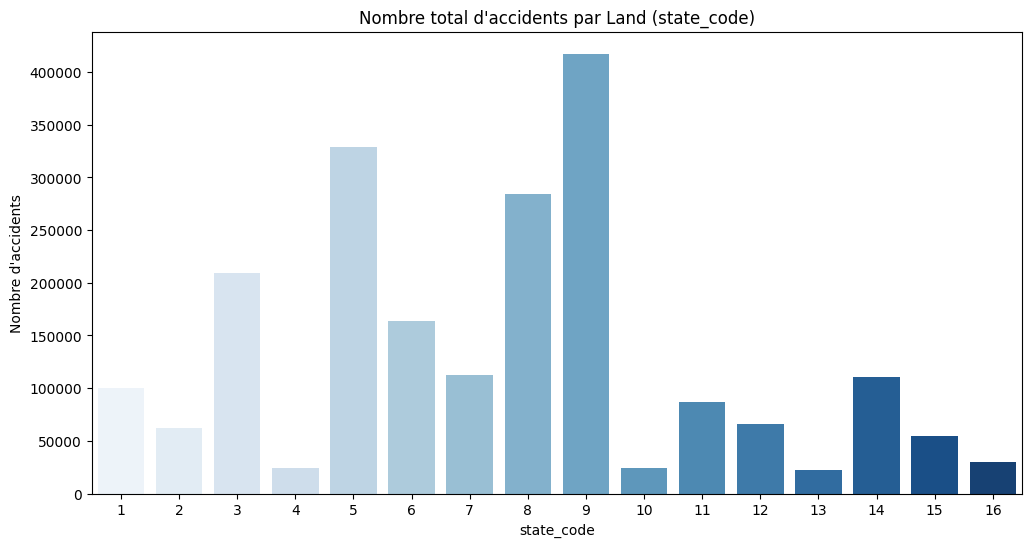

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

acc_by_land = df_merged.groupby("state_code")["accident_count"].sum()

plt.figure(figsize=(12,6))
sns.barplot(x=acc_by_land.index, y=acc_by_land.values, palette="Blues")
plt.title("Nombre total d'accidents par Land (state_code)")
plt.xlabel("state_code")
plt.ylabel("Nombre d'accidents")
plt.show()

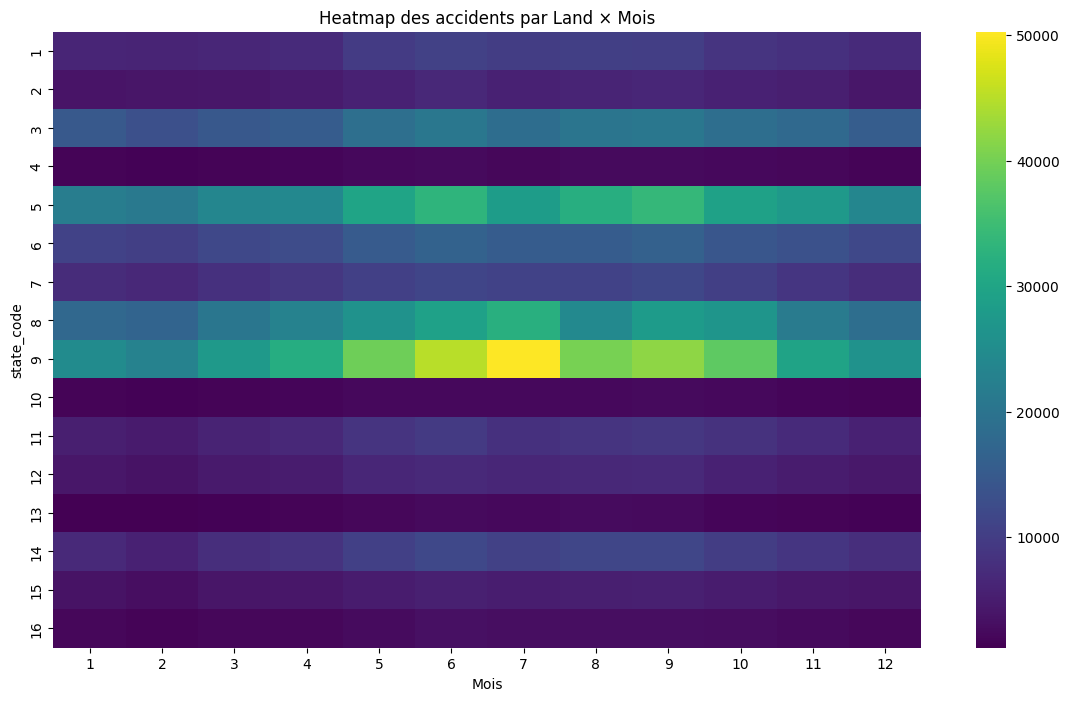

In [56]:
acc_month_land = (
    df_merged.groupby(["state_code", "month"])["accident_count"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14,8))
sns.heatmap(acc_month_land, cmap="viridis")
plt.title("Heatmap des accidents par Land × Mois")
plt.xlabel("Mois")
plt.ylabel("state_code")
plt.show()

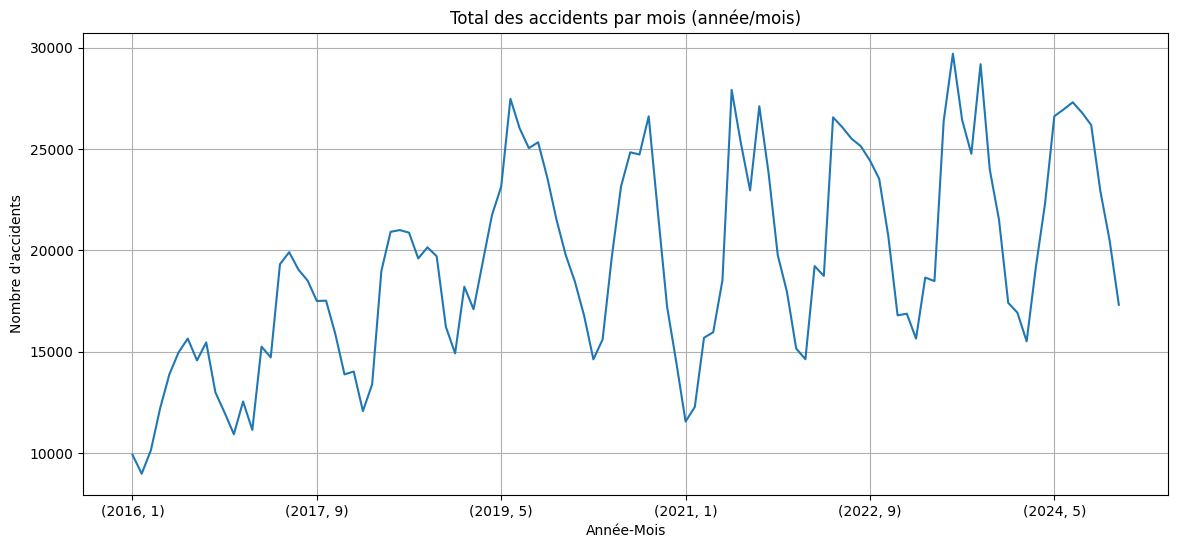

In [8]:
acc_ts = (
    df_merged.groupby(["year", "month"])["accident_count"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(14,6))
acc_ts.plot()
plt.title("Total des accidents par mois (année/mois)")
plt.xlabel("Année-Mois")
plt.ylabel("Nombre d'accidents")
plt.grid(True)
plt.show()

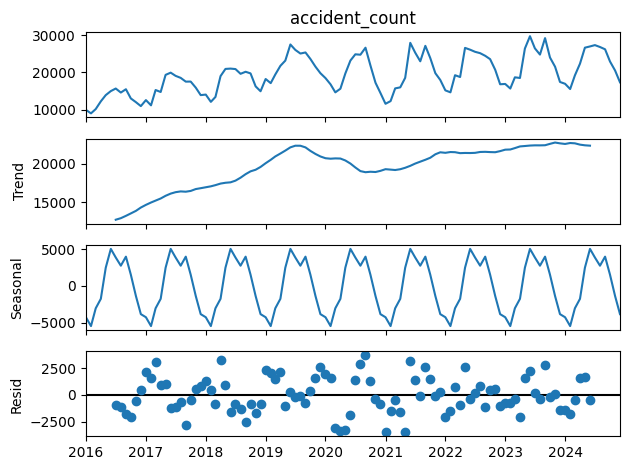

In [58]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = (
    df_merged.groupby(["year", "month"])["accident_count"]
    .sum()
)

# créer un index DateTime temporaire
ts.index = [f"{y}-{m:02d}-01" for (y,m) in ts.index]
ts.index = pd.to_datetime(ts.index)
ts = ts.asfreq("MS")

result = seasonal_decompose(ts, model="additive", period=12)
result.plot()
plt.show()


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



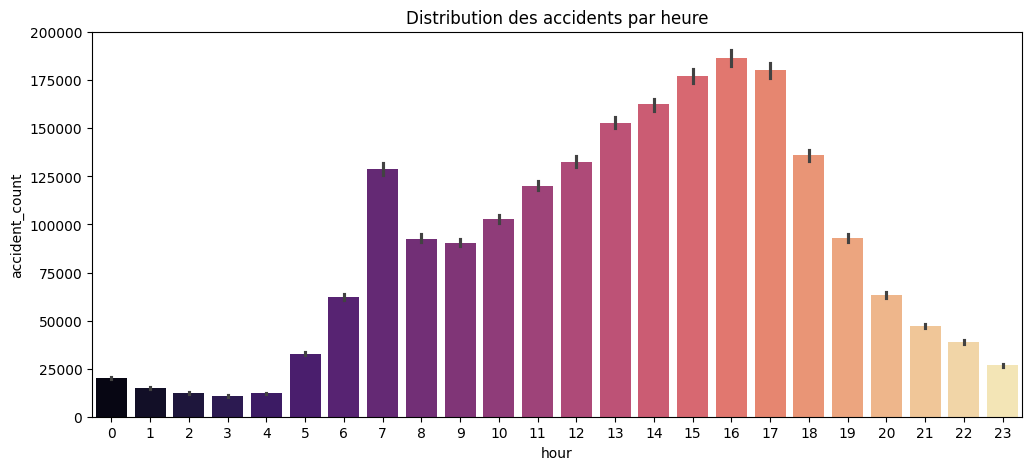

In [59]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=df_merged,
    x="hour",
    y="accident_count",
    estimator=sum,
    palette="magma"
)
plt.title("Distribution des accidents par heure")
plt.show()


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



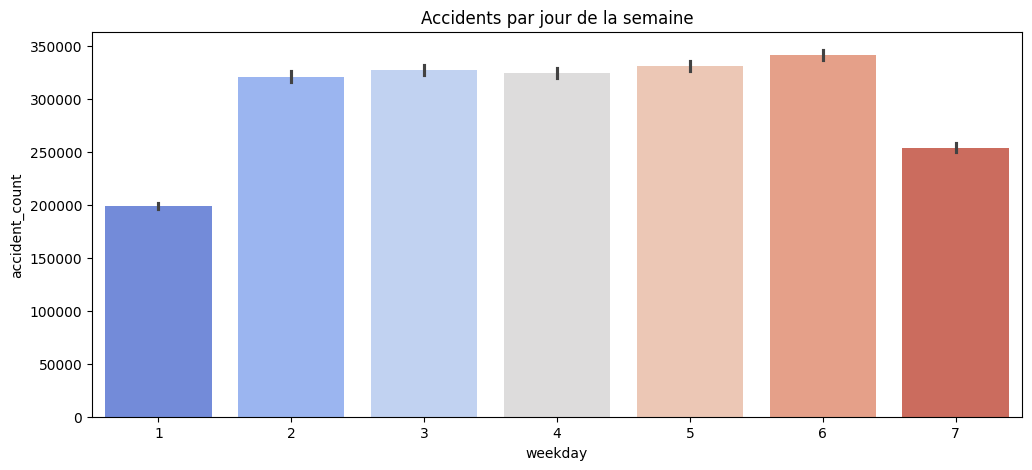

In [60]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=df_merged,
    x="weekday",
    y="accident_count",
    estimator=sum,
    palette="coolwarm"
)
plt.title("Accidents par jour de la semaine")
plt.show()

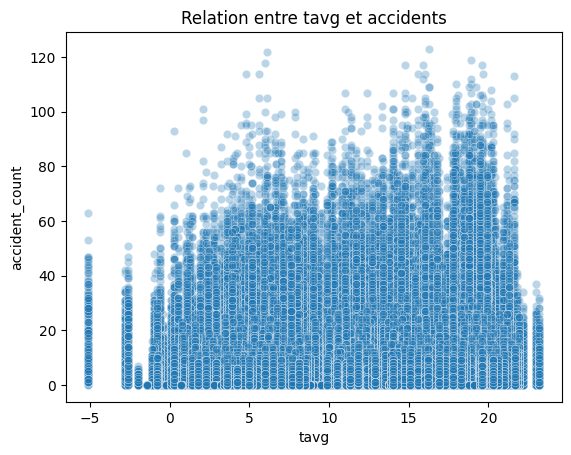

In [61]:
sns.scatterplot(data=df_merged, x="tavg", y="accident_count", alpha=0.3)
plt.title("Relation entre tavg et accidents")
plt.show()

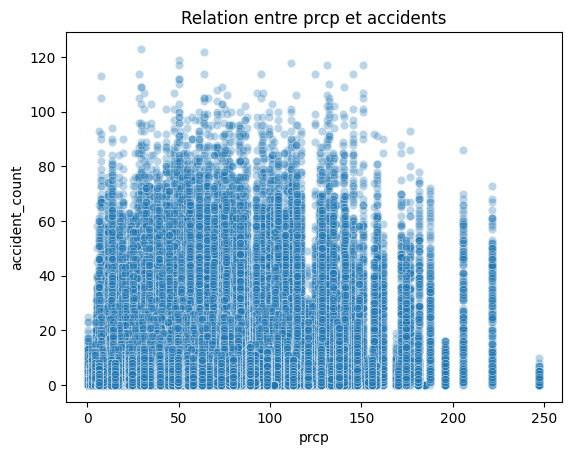

In [62]:
sns.scatterplot(data=df_merged, x="prcp", y="accident_count", alpha=0.3)
plt.title("Relation entre prcp et accidents")
plt.show()

In [9]:
df_merged = df_merged.sort_values(["year", "month", "weekday", "hour"])
df_merged = df_merged.reset_index(drop=True)

In [10]:
df_merged

,state_code,year,month,weekday,hour,region_code,district_code,municipality_code,latitude,longitude,...,is_weekend,is_rush_hour,is_night,is_morning,is_afternoon,is_evening,is_winter,is_summer,is_autumn,is_spring
0,1,2016,1,1,0,0,53,120,"53,729614888000000","10,621659329000000",...,0,0,1,0,0,0,1,0,0,0
1,2,2016,1,1,0,7,9,710,"53,450085612000002","9,967262657999999",...,0,0,1,0,0,0,1,0,0,0
2,3,2016,1,1,0,3,60,25,"52,956923146000065","10,603023863000033",...,0,0,1,0,0,0,1,0,0,0
3,4,2016,1,1,0,0,11,0,"53,028534780000001","8,857319255000000",...,0,0,1,0,0,0,1,0,0,0
4,5,2016,1,1,0,3,34,2,"50,771039641000073","6,115586038000060",...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290299,12,2024,12,7,23,0,69,485,"52,034004167000035","12,617578560000027",...,1,0,0,0,0,1,1,0,0,0
290300,13,2024,12,7,23,0,74,87,"53,894285004000039","11,478312723000045",...,1,0,0,0,0,1,1,0,0,0
290301,14,2024,12,7,23,6,27,140,"51,160793257000002","13,473429811999999",...,1,0,0,0,0,1,1,0,0,0
290302,15,2024,12,7,23,0,88,305,"51,403088129000082","11,587106278000022",...,1,0,0,0,0,1,1,0,0,0


In [13]:
feature_list = [
    "state_code", "year", "month", "weekday", "hour",
    "region_code", "district_code", "municipality_code",
    "tavg", "prcp",
    "is_weekend", "is_rush_hour",
    "is_night", "is_morning", "is_afternoon", "is_evening",
    "is_winter", "is_summer", "is_autumn", "is_spring"
]

df_merged = df_merged.sort_values(
    ["year", "month", "weekday", "hour"]
).reset_index(drop=True)

test_size = 72

training_data = df_merged.iloc[:-test_size].copy()
testing_data  = df_merged.iloc[-test_size:].copy()

X_train = training_data[feature_list]
y_train = training_data["accident_count"]

X_test = testing_data[feature_list]
y_test = testing_data["accident_count"]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (290232, 20) (290232,)
Test: (72, 20) (72,)


In [14]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

In [15]:
cv_split = TimeSeriesSplit(n_splits=4, test_size=100)
model = XGBRegressor(
    objective="count:poisson",
    eval_metric="poisson-nloglik",
    random_state=42
)
param_grid = {
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [300, 500],
    "colsample_bytree": [0.8],
    "subsample": [0.8]
}

In [16]:
grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv_split,
        n_jobs=-1,
        verbose=0
)

In [17]:
grid_search.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8], 'learning_rate': [0.05, 0.1], 'max_depth': [4, 6], 'n_estimators': [300, 500], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...test_size=100)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'count:poisson'


In [22]:
y_test

290232    16
290233     1
290234     5
290235     2
290236     1
          ..
290299     1
290300     2
290301     2
290302     1
290303     1
Name: accident_count, Length: 72, dtype: int64

In [23]:
y_pred = grid_search.predict(X_test)

In [24]:
y_pred

array([14.050353  ,  1.2749413 ,  5.264232  ,  2.5492792 ,  1.3679541 ,
        3.8711994 ,  2.2299702 ,  1.6528348 ,  2.7239227 ,  2.2786117 ,
        7.6282463 ,  0.8332962 , 18.616814  ,  5.412083  ,  3.1527765 ,
        8.254085  , 10.280337  ,  1.0150129 ,  4.015182  ,  1.8891379 ,
        1.0579336 ,  2.6685517 ,  1.8969686 ,  1.2713076 ,  2.4632845 ,
        1.9849902 ,  6.4938307 ,  0.74145365, 16.789642  ,  4.484321  ,
        2.741845  ,  6.195454  ,  8.029198  ,  0.9181359 ,  3.2200892 ,
        1.6281    ,  0.95844007,  2.438421  ,  1.4989256 ,  1.1594329 ,
        2.2853174 ,  1.96838   ,  6.335782  ,  0.6301778 , 16.899433  ,
        4.377884  ,  2.553045  ,  6.020775  ,  7.7545075 ,  0.86466247,
        2.9209101 ,  1.5881834 ,  0.9404987 ,  2.356954  ,  1.4945458 ,
        1.1415133 ,  2.3011255 ,  2.0648537 ,  6.1446924 ,  0.6476694 ,
       16.186678  ,  4.258988  ,  2.5322027 ,  5.9020185 ,  7.286719  ,
        0.81719863,  3.1534617 ,  1.418225  ,  0.9211864 ,  2.29

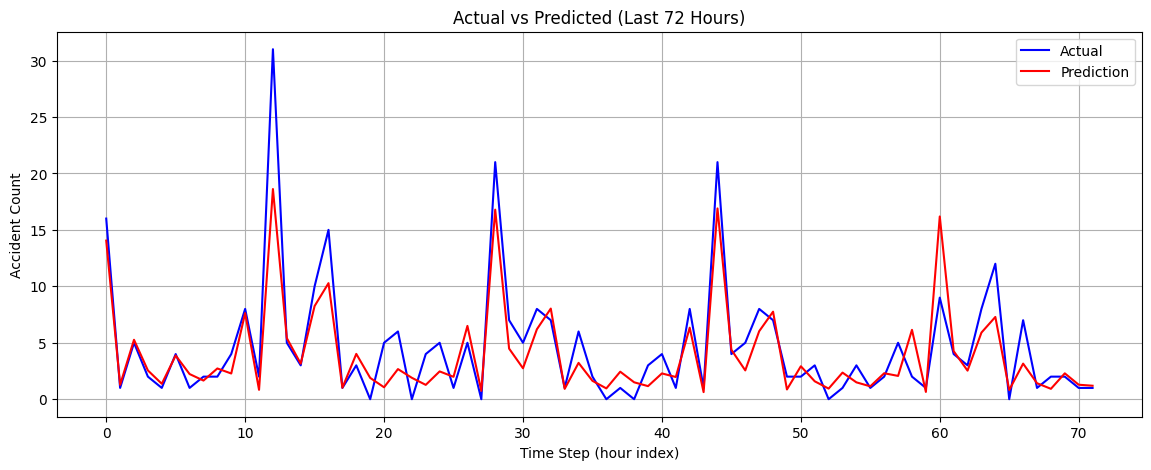

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,5))

plt.plot(np.arange(len(y_test)), y_test, label="Actual", color="blue")
plt.plot(np.arange(len(y_pred)), y_pred, label="Prediction", color="red")

plt.title("Actual vs Predicted (Last 72 Hours)")
plt.xlabel("Time Step (hour index)")
plt.ylabel("Accident Count")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

def evaluate_model(y_test, prediction):
  print(f"MAE: {mean_absolute_error(y_test, prediction)}")
  print(f"MSE: {mean_squared_error(y_test, prediction)}")

In [29]:
evaluate_model(y_test, y_pred)

MAE: 1.681257724761963
MSE: 6.350530624389648


In [30]:
import joblib

# Sauvegarde
joblib.dump(grid_search, "model.pkl")

['model.pkl']